In [34]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [35]:
df = pd.read_csv('../data/processed/titanic_cleaned.csv')

X = df.drop('Survived', axis=1)
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=8)
}

for name, model in models.items():
    model.fit(x_train, y_train) 
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.2f}")

Random Forest Accuracy: 0.82
Logistic Regression Accuracy: 0.80
K-Nearest Neighbors Accuracy: 0.70


In [37]:
params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=params, cv=5, scoring='accuracy')

grid_search.fit(x_train, y_train)

best_forest = grid_search.best_estimator_

acc = best_forest.score(x_test, y_test)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best accuracy: {acc:.2f}")

Best parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best accuracy: 0.80


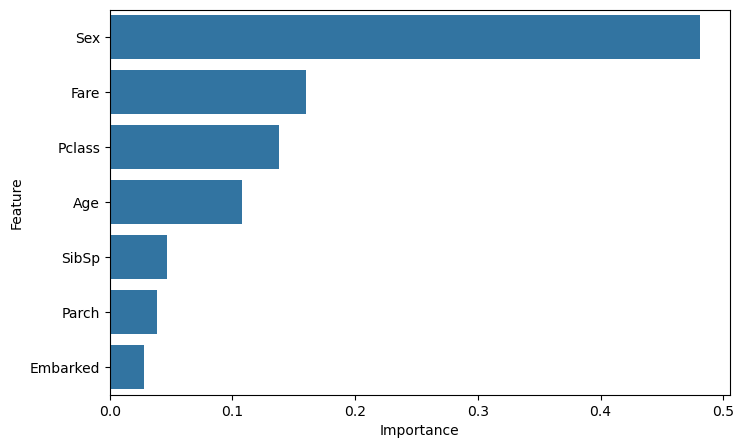

In [44]:
importances = best_forest.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5)) 
sns.barplot(x='Importance', y='Feature', data=importance_df)

plt.show()

In [45]:
y_pred = best_forest.predict(x_test)

print(classification_report(y_test, y_pred, target_names=['Погиб', 'Выжил']))



              precision    recall  f1-score   support

       Погиб       0.80      0.88      0.84       105
       Выжил       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



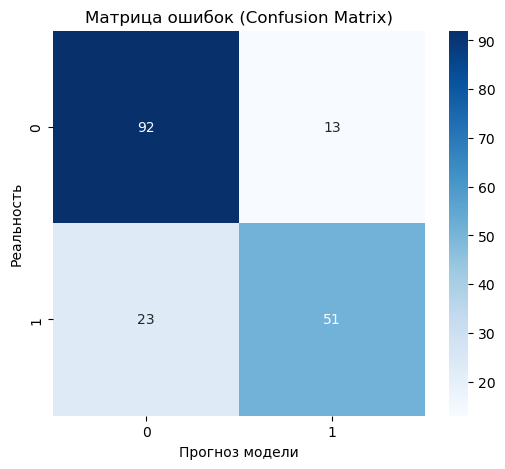

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Реальность')
plt.xlabel('Прогноз модели')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

In [48]:
import joblib
joblib.dump(best_forest, '../models/titanic_model.pkl')

['../models/titanic_model.pkl']